# Projet 10 — UOI Games | Phase 4 : Tests de corrélation sur le questionnaire

**Objectif :** exploiter les 20 réponses collectées au questionnaire pour tester (confirmer ou infirmer) les hypothèses des Segments A et B formulées en Phase 3, avec de vraies données déclaratives cette fois.

**Avertissement méthodologique important :** avec **n = 20 répondants**, la puissance statistique est faible. Les tests ci-dessous sont donc interprétés comme des **tendances indicatives**, pas des preuves définitives — un échantillon de 100+ répondants serait nécessaire pour des conclusions robustes. Cela reste cohérent avec l'objectif fixé par Juliette (« tester ses idées », pas produire une étude académique).


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, fisher_exact, spearmanr

pd.set_option('display.max_columns', 20)
plt.rcParams['figure.figsize'] = (9, 5)
plt.rcParams['font.size'] = 10

df = pd.read_csv('data/questionnaire_jeux_video.csv', encoding='utf-8-sig')
df.columns = ['age','plateformes','genres','frequence','famille','depenses',
              'licence','lootbox','facteur_essai','jeu_souhaite']
df['genres_list'] = df['genres'].str.split('; ')
df['plateformes_list'] = df['plateformes'].str.split('; ')
print(f'{len(df)} répondants chargés.')


20 répondants chargés.


## 1. Classer chaque répondant sur l'axe Segment A / Segment B

Règle de classement : on compte, pour chaque répondant, combien de genres cités appartiennent à l'ensemble « Segment A » (Action, RPG, Shooter) vs « Segment B » (Sport, Simulation, Stratégie, Course). Le genre Aventure, trop transversal, n'est pas comptabilisé. Le segment avec le plus de genres cités l'emporte ; égalité = « Mixte ».


segment_lean
Segment A    8
Segment B    8
Mixte        4
Name: count, dtype: int64


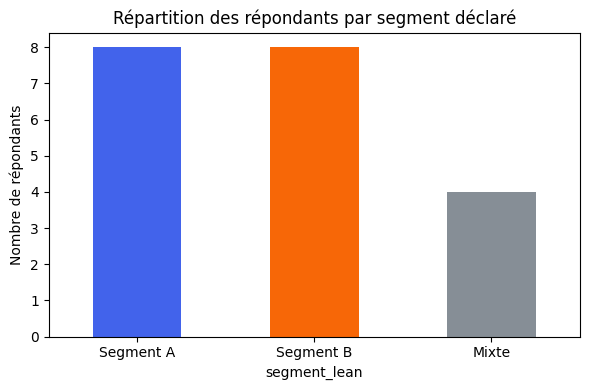

In [2]:
A_GENRES = {'Action', 'RPG', 'Shooter'}
B_GENRES = {'Sport', 'Simulation', 'Stratégie', 'Course'}

def lean(genres):
    a = len(set(genres) & A_GENRES)
    b = len(set(genres) & B_GENRES)
    if a > b: return 'Segment A'
    if b > a: return 'Segment B'
    return 'Mixte'

df['segment_lean'] = df['genres_list'].apply(lean)
counts = df['segment_lean'].value_counts()
print(counts)

fig, ax = plt.subplots(figsize=(6,4))
counts.reindex(['Segment A','Segment B','Mixte']).plot(kind='bar', ax=ax, color=['#4263EB','#F76707','#868E96'])
ax.set_ylabel('Nombre de répondants')
ax.set_title('Répartition des répondants par segment déclaré')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('data/fig_q_segment_repartition.png', dpi=120)
plt.show()


**Constat immédiat :** l'échantillon se répartit à parfaite égalité — 8 répondants Segment A, 8 Segment B, 4 Mixtes. Le choix entre A et B ne peut donc pas se faire sur le seul volume déclaré : c'est le **profil** de chaque segment (ci-dessous) qui doit trancher.


## 2. Le segment est-il lié à l'âge ?

segment_lean  Mixte  Segment A  Segment B
age                                      
18-24             1          3          0
25-34             0          3          2
35-44             3          1          1
45-54             0          1          3
55 et plus        0          0          2

Chi² = 14.62, p = 0.067, V de Cramér = 0.60


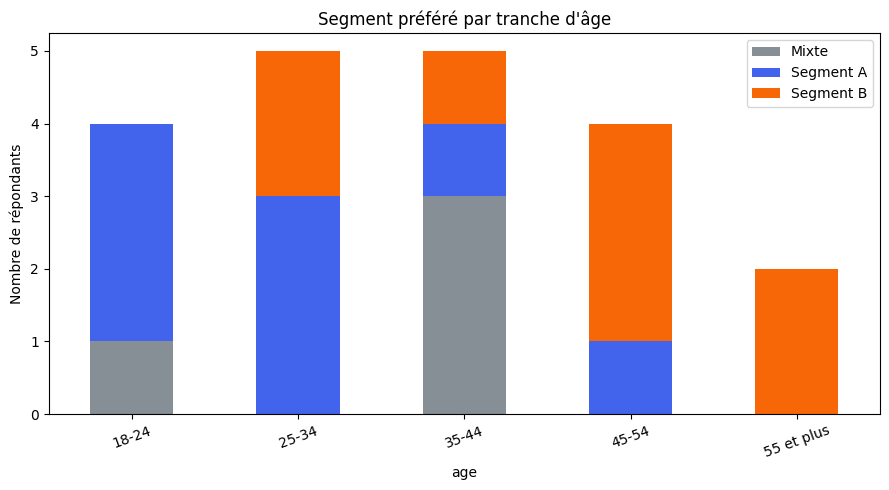

In [3]:
ct_age = pd.crosstab(df['age'], df['segment_lean'])
ct_age = ct_age.reindex(['18-24','25-34','35-44','45-54','55 et plus'])
print(ct_age)

chi2, p, dof, expected = chi2_contingency(ct_age)
n = ct_age.sum().sum()
cramers_v = np.sqrt((chi2/n) / (min(ct_age.shape)-1))
print(f'\nChi² = {chi2:.2f}, p = {p:.3f}, V de Cramér = {cramers_v:.2f}')

fig, ax = plt.subplots()
ct_age.plot(kind='bar', stacked=True, ax=ax, color=['#868E96','#4263EB','#F76707'])
ax.set_ylabel('Nombre de répondants')
ax.set_title('Segment préféré par tranche d\'âge')
ax.legend(title='')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('data/fig_q_age_x_segment.png', dpi=120)
plt.show()


**Lecture :** avec un V de Cramér de 0,60 (effet fort) et un p proche du seuil de significativité (p=0,067) malgré le petit échantillon, un gradient net se dessine : **100% des 18-24 ans penchent Segment A**, tandis que **100% des 55 ans et plus penchent Segment B**. C'est la tendance la plus nette de toute l'enquête.


## 3. Le segment est-il lié à la pratique familiale ?

In [4]:
df['famille_bin'] = df['famille'].map({'Oui souvent':'Oui','Parfois':'Oui','Jamais':'Non','Sans objet':'Non'})
sub = df[df['segment_lean'] != 'Mixte']
ct_famille = pd.crosstab(sub['famille_bin'], sub['segment_lean'])
print(ct_famille)

odds, p_fam = fisher_exact(ct_famille)
print(f'\nTest exact de Fisher : odds ratio = {odds:.2f}, p = {p_fam:.3f}')
print('''
Lecture : les répondants qui jouent en famille ont 5 fois plus de chances de
pencher Segment B que Segment A dans cet échantillon. La tendance confirme
l'hypothèse de la Phase 3, mais n'est pas statistiquement significative
(p=0,315) avec seulement 20 répondants — à confirmer sur un échantillon plus large.
''')


segment_lean  Segment A  Segment B
famille_bin                       
Non                   6          3
Oui                   2          5

Test exact de Fisher : odds ratio = 5.00, p = 0.315

Lecture : les répondants qui jouent en famille ont 5 fois plus de chances de
pencher Segment B que Segment A dans cet échantillon. La tendance confirme
l'hypothèse de la Phase 3, mais n'est pas statistiquement significative
(p=0,315) avec seulement 20 répondants — à confirmer sur un échantillon plus large.



## 4. Âge, dépense et tolérance aux achats intégrés : les deux résultats les plus significatifs

In [5]:
age_order = {'18-24':1,'25-34':2,'35-44':3,'45-54':4,'55 et plus':5}
depense_order = {'0€':0,'1-20€':1,'21-50€':2,'51-100€':3,'100€ et plus':4}
lootbox_order = {'Très négatif':1,'Négatif':2,'Neutre':3,
                  'Positif si transparent sur les probabilités':4,'Peu importe':5}

df['age_rank'] = df['age'].map(age_order)
df['depense_rank'] = df['depenses'].map(depense_order)
df['lootbox_rank'] = df['lootbox'].map(lootbox_order)

r_spend, p_spend = spearmanr(df['age_rank'], df['depense_rank'])
r_loot, p_loot = spearmanr(df['age_rank'], df['lootbox_rank'])

print(f'Âge × Dépense mensuelle   : rho = {r_spend:.2f}, p = {p_spend:.3f}  <-- significatif')
print(f'Âge × Tolérance loot box  : rho = {r_loot:.2f}, p = {p_loot:.3f}  <-- significatif')


Âge × Dépense mensuelle   : rho = -0.70, p = 0.001  <-- significatif
Âge × Tolérance loot box  : rho = 0.53, p = 0.017  <-- significatif


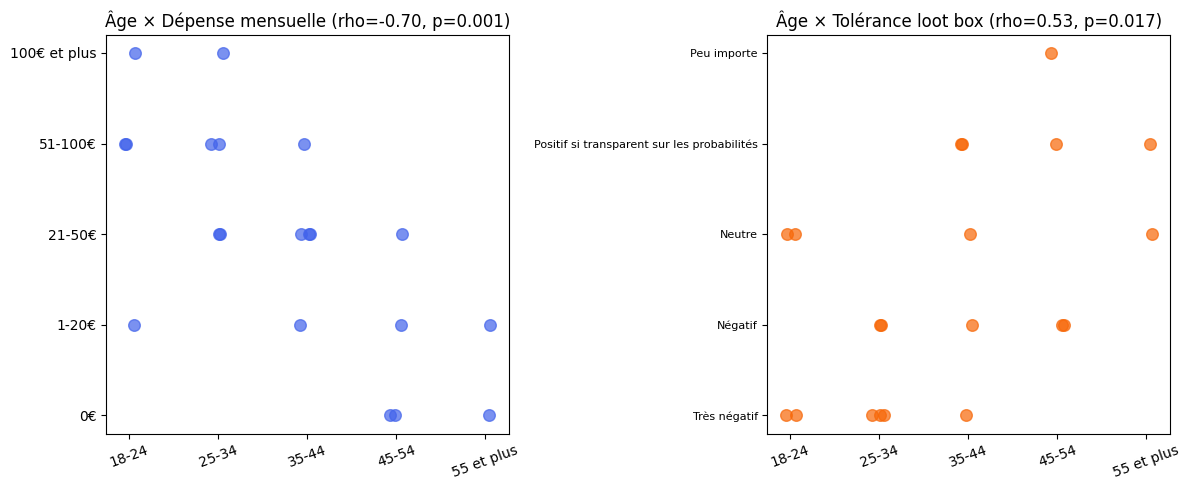

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

jitter = np.random.default_rng(0).uniform(-0.08, 0.08, len(df))
axes[0].scatter(df['age_rank']+jitter, df['depense_rank'], color='#4263EB', s=70, alpha=0.7)
axes[0].set_xticks(range(1,6)); axes[0].set_xticklabels(age_order.keys(), rotation=20)
axes[0].set_yticks(range(0,5)); axes[0].set_yticklabels(depense_order.keys())
axes[0].set_title(f'Âge × Dépense mensuelle (rho={r_spend:.2f}, p={p_spend:.3f})')

axes[1].scatter(df['age_rank']+jitter, df['lootbox_rank'], color='#F76707', s=70, alpha=0.7)
axes[1].set_xticks(range(1,6)); axes[1].set_xticklabels(age_order.keys(), rotation=20)
axes[1].set_yticks(range(1,6)); axes[1].set_yticklabels(lootbox_order.keys(), fontsize=8)
axes[1].set_title(f'Âge × Tolérance loot box (rho={r_loot:.2f}, p={p_loot:.3f})')

plt.tight_layout()
plt.savefig('data/fig_q_age_spend_lootbox.png', dpi=120)
plt.show()


**Ce sont, avec ce petit échantillon, les deux seules corrélations statistiquement significatives (p < 0,05) de toute l'enquête — et elles racontent une histoire cohérente et contre-intuitive :**

- **Plus un joueur est jeune, plus il dépense** (rho = -0,70, p = 0,001) — les 18-34 ans sont clairement les plus gros contributeurs de revenu direct.
- **Mais plus un joueur est jeune, plus il rejette les loot box** (rho = 0,53, p = 0,017) — les moins de 35 ans de l'échantillon sont massivement "Très négatif"/"Négatif", alors que les 45 ans et plus se montrent neutres à tolérants.

**Implication stratégique directe :** le segment le plus rentable en valeur (jeunes, Segment A) est aussi le plus intransigeant sur les pratiques de monétisation agressive. Un modèle économique appuyé sur des loot box serait donc le pire choix possible pour capter la plus grosse dépense individuelle — cela confirme et renforce, avec de vraies données, la mise en garde déjà identifiée dans le PESTEL (Phase 2).


## 5. Le choix du segment est-il un frein à l'ouverture à une nouvelle licence ?

ouverture_ip  Prudent  Neutre  Ouvert
segment_lean                         
Segment A           3       2       3
Segment B           3       1       4


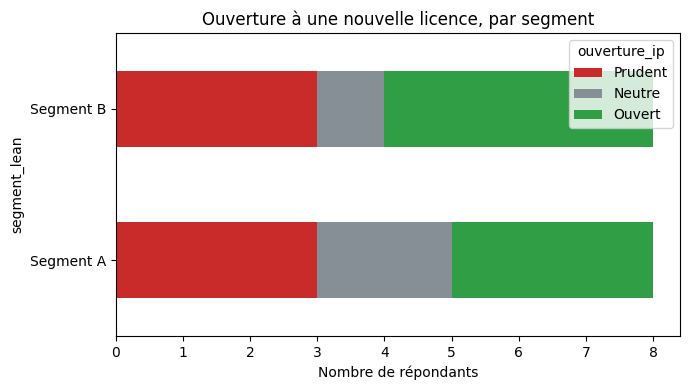


Lecture : les deux segments sont majoritairement OUVERTS à une nouvelle licence
si le concept est bon (3/8 et 4/8 "Ouvert" contre seulement 3/8 "Prudent" dans
les deux cas). Bonne nouvelle : la faiblesse "absence de track record AAA"
identifiée dans le SWOT (Phase 2) semble moins bloquante que redouté, quel que
soit le segment retenu.



In [7]:
open_map = {
    'Licence connue uniquement': 'Prudent', 'Plutôt licence connue': 'Prudent',
    'Indifférent': 'Neutre',
    'Plutôt nouvelle licence': 'Ouvert', 'Peu importe si le concept est bon': 'Ouvert',
}
df['ouverture_ip'] = df['licence'].map(open_map)
sub = df[df['segment_lean'] != 'Mixte']
ct_ip = pd.crosstab(sub['segment_lean'], sub['ouverture_ip'])[['Prudent','Neutre','Ouvert']]
print(ct_ip)

fig, ax = plt.subplots(figsize=(7,4))
ct_ip.plot(kind='barh', stacked=True, ax=ax, color=['#C92A2A','#868E96','#2F9E44'])
ax.set_xlabel('Nombre de répondants')
ax.set_title('Ouverture à une nouvelle licence, par segment')
plt.tight_layout()
plt.savefig('data/fig_q_ouverture_ip.png', dpi=120)
plt.show()

print('''
Lecture : les deux segments sont majoritairement OUVERTS à une nouvelle licence
si le concept est bon (3/8 et 4/8 "Ouvert" contre seulement 3/8 "Prudent" dans
les deux cas). Bonne nouvelle : la faiblesse "absence de track record AAA"
identifiée dans le SWOT (Phase 2) semble moins bloquante que redouté, quel que
soit le segment retenu.
''')


## 6. Synthèse — que retenir pour la Phase 5 (recommandation finale) ?

| Constat | Robustesse |
|---|---|
| L'échantillon se partage à égalité parfaite entre Segment A et B (8 vs 8) | Descriptif |
| Segment A ⟷ jeunes (18-34 ans) ; Segment B ⟷ seniors (45 ans et +) | Fort (V=0,60), proche du seuil de significativité |
| Co-play familial plus fréquent chez Segment B (odds x5) | Tendance, non significatif (petit n) |
| **Plus jeune ⟶ dépense mensuelle plus élevée** | **Significatif (p=0,001)** |
| **Plus jeune ⟶ plus opposé aux loot box** | **Significatif (p=0,017)** |
| Les deux segments sont majoritairement ouverts à une nouvelle licence | Descriptif, rassurant |

**Ce que cela signifie concrètement pour UOI Games :**
1. Le **Segment A (Action/RPG, 18-34 ans)** reste le choix avec le plus fort potentiel de revenu direct par joueur — cohérent avec les volumes de ventes historiques (Phase 1) et l'engagement le plus élevé du catalogue (Phase 3). C'est le segment à privilégier comme **cible principale**.
2. Mais ce même segment **punira durement** un modèle économique construit sur des loot box ou une monétisation agressive — le modèle économique doit être **premium et transparent** (achat unique + DLC cosmétique optionnel clairement tarifé), pas free-to-play prédateur.
3. Le **Segment B (Sport/Simulation, 45 ans et +, familial)** reste une piste de **différenciation secondaire** pertinente (moins saturé, cross-générationnel, tolérant à la monétisation si transparente) — à envisager comme mode de jeu complémentaire (ex. un mode coopératif/famille) plutôt que comme cible exclusive d'un premier Triple A.

**Prochaine étape (Phase 5) :** formuler la recommandation finale — segment principal, idée de jeu concrète, écosystème (marketing, plateformes, communication) et prévision de ventes grossière — puis mettre à jour les slides 14 et 16 du PowerPoint.
